In [189]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics._regression import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [190]:
df = pd.read_csv( '../data/raw/Heart-Disease-Patients-Records.csv' )

In [191]:
df

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
0,52,male,typical angina,125,212,lower than 120mg/ml,ST-T wave abnormality,168,no,1.0,downsloping,2,reversable defect,Diagnosed
1,53,male,typical angina,140,203,higher than 120mg/ml,normal,155,yes,3.1,upsloping,0,reversable defect,Diagnosed
2,70,male,typical angina,145,174,lower than 120mg/ml,ST-T wave abnormality,125,yes,2.6,upsloping,0,reversable defect,Diagnosed
3,61,male,typical angina,148,203,lower than 120mg/ml,ST-T wave abnormality,161,no,0.0,downsloping,1,reversable defect,Diagnosed
4,62,female,typical angina,138,294,higher than 120mg/ml,ST-T wave abnormality,106,no,1.9,flat,3,fixed defect,Diagnosed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,male,atypical angina,140,221,lower than 120mg/ml,ST-T wave abnormality,164,yes,0.0,downsloping,0,fixed defect,Un-Diagnosed
1021,60,male,typical angina,125,258,lower than 120mg/ml,normal,141,yes,2.8,flat,1,reversable defect,Diagnosed
1022,47,male,typical angina,110,275,lower than 120mg/ml,normal,118,yes,1.0,flat,1,fixed defect,Diagnosed
1023,50,female,typical angina,110,254,lower than 120mg/ml,normal,159,no,0.0,downsloping,0,fixed defect,Un-Diagnosed


In [192]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resisting_blood_pressure',
       'cholesterol_level', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'diagnosis'],
      dtype='object')

In [193]:
df['diagnosis']=df['diagnosis'].map({'Un-Diagnosed': 0, 'Diagnosed': 1})

In [194]:
X = df.drop( columns = 'diagnosis' )
y = df['diagnosis']

In [195]:
X

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia
0,52,male,typical angina,125,212,lower than 120mg/ml,ST-T wave abnormality,168,no,1.0,downsloping,2,reversable defect
1,53,male,typical angina,140,203,higher than 120mg/ml,normal,155,yes,3.1,upsloping,0,reversable defect
2,70,male,typical angina,145,174,lower than 120mg/ml,ST-T wave abnormality,125,yes,2.6,upsloping,0,reversable defect
3,61,male,typical angina,148,203,lower than 120mg/ml,ST-T wave abnormality,161,no,0.0,downsloping,1,reversable defect
4,62,female,typical angina,138,294,higher than 120mg/ml,ST-T wave abnormality,106,no,1.9,flat,3,fixed defect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,male,atypical angina,140,221,lower than 120mg/ml,ST-T wave abnormality,164,yes,0.0,downsloping,0,fixed defect
1021,60,male,typical angina,125,258,lower than 120mg/ml,normal,141,yes,2.8,flat,1,reversable defect
1022,47,male,typical angina,110,275,lower than 120mg/ml,normal,118,yes,1.0,flat,1,fixed defect
1023,50,female,typical angina,110,254,lower than 120mg/ml,normal,159,no,0.0,downsloping,0,fixed defect


In [196]:
y

0       1
1       1
2       1
3       1
4       1
       ..
1020    0
1021    1
1022    1
1023    0
1024    1
Name: diagnosis, Length: 1025, dtype: int64

In [197]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [198]:
X_train.shape

(820, 13)

In [199]:
y_train.shape

(820,)

In [200]:
print(X_train.dtypes)

age                           int64
sex                          object
chest_pain_type              object
resisting_blood_pressure      int64
cholesterol_level             int64
fasting_blood_sugar          object
rest_ecg                     object
max_heart_rate_achieved       int64
exercise_induced_angina      object
st_depression               float64
st_slope                     object
num_major_vessels             int64
thalassemia                  object
dtype: object


In [201]:
X = pd.get_dummies(X, drop_first=True)
X_train = X_train  # already split
X_test = X_test    # already split

In [202]:
# Convert categorical features
X = pd.get_dummies(X, drop_first=True)

# Now split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [203]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [204]:
from sklearn.preprocessing import StandardScaler

In [205]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [206]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [207]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [208]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

# Model Selection

## [1] KNN

In [209]:
knn_model = KNeighborsClassifier(  )

In [210]:
knn_model.fit( X_train, y_train )

KNeighborsClassifier()

In [211]:
X_train

array([[-0.58584022, -0.77945357, -1.93503098, ...,  0.93388764,
        -0.26286953, -0.81442373],
       [ 1.05147737,  2.74173173,  1.61063407, ...,  0.93388764,
        -0.26286953, -0.81442373],
       [-0.04006769, -1.34738668,  0.44217627, ...,  0.93388764,
        -0.26286953, -0.81442373],
       ...,
       [-0.36753121,  0.46999928,  1.08684264, ..., -1.07079263,
        -0.26286953,  1.22786207],
       [-1.24076726, -1.23380006, -0.68598988, ..., -1.07079263,
        -0.26286953,  1.22786207],
       [-0.2583767 , -1.12021343, -0.30321922, ...,  0.93388764,
        -0.26286953, -0.81442373]], shape=(820, 19))

In [212]:
y_train

835    1
137    0
534    0
495    0
244    0
      ..
700    0
71     1
106    1
270    0
860    1
Name: diagnosis, Length: 820, dtype: int64

In [213]:
y_pred_train = knn_model.predict( X_train )
y_pred_train

array([1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,

In [214]:
acc_train = accuracy_score( y_true= y_train, y_pred= y_pred_train) * 100
print( f'Training Acc: { acc_train }' )

Training Acc: 95.48780487804878


#### Compute model predictions (test)

In [215]:
y_pred_test = knn_model.predict( X_test )
y_pred_test

array([0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1])

In [216]:
conf_mat = confusion_matrix( y_test, y_pred_test )   # 2D
conf_mat

array([[91, 12],
       [17, 85]])

#### Visualize Confusion Matrix

### annot --> annotation

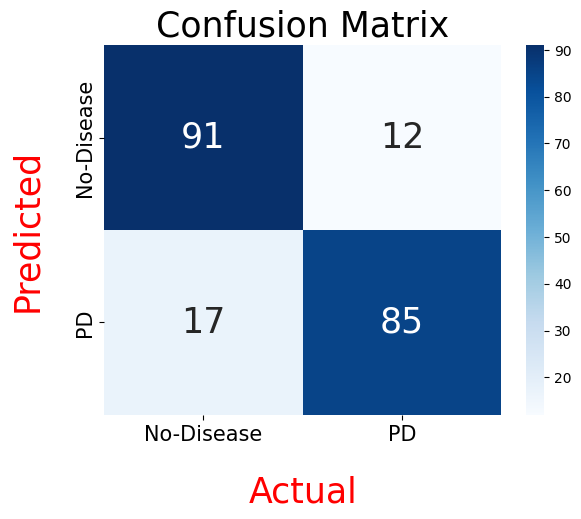

In [217]:
sns.heatmap( conf_mat, cmap = 'Blues', annot= True,
             annot_kws= { 'fontsize' : 25 });
plt.title( 'Confusion Matrix', fontsize = 25 );
plt.xticks( [0.5, 1.5], labels = [ 'No-Disease', 'PD' ], fontsize = 15 ); plt.xlabel( 'Actual', fontsize = 25, labelpad= 22, color = 'red' )
plt.yticks( [ 0.5, 1.5 ], labels = [ 'No-Disease', 'PD' ], fontsize = 15  ); plt.ylabel( 'Predicted', fontsize = 25, labelpad= 22, color = 'red' );

In [218]:
acc_test = ( 85 + 91 ) / ( 85+17+91+12 ) * 100
acc_test

85.85365853658537

In [219]:
accuracy_score( y_test, y_pred_test )

0.8585365853658536

In [220]:
print( f'Training Acc for KNN : { acc_train }' )
print( f'Testing Acc for KNN : { acc_test }'  )

Training Acc for KNN : 95.48780487804878
Testing Acc for KNN : 85.85365853658537


In [221]:
X_train

array([[-0.58584022, -0.77945357, -1.93503098, ...,  0.93388764,
        -0.26286953, -0.81442373],
       [ 1.05147737,  2.74173173,  1.61063407, ...,  0.93388764,
        -0.26286953, -0.81442373],
       [-0.04006769, -1.34738668,  0.44217627, ...,  0.93388764,
        -0.26286953, -0.81442373],
       ...,
       [-0.36753121,  0.46999928,  1.08684264, ..., -1.07079263,
        -0.26286953,  1.22786207],
       [-1.24076726, -1.23380006, -0.68598988, ..., -1.07079263,
        -0.26286953,  1.22786207],
       [-0.2583767 , -1.12021343, -0.30321922, ...,  0.93388764,
        -0.26286953, -0.81442373]], shape=(820, 19))

In [222]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## [1] ~ Try Scaling with KNN

In [223]:
knn_pipeline = Pipeline([
    ( 'Scaling', StandardScaler() ),
    ( 'KNN-Model', KNeighborsClassifier() )
])
knn_pipeline

Pipeline(steps=[('Scaling', StandardScaler()),
                ('KNN-Model', KNeighborsClassifier())])

In [224]:
#knn_pipeline.fit( X_train, y_train )


In [225]:
'''acc_train = knn_pipeline.score( X_train, y_train ) * 100
acc_test = knn_pipeline.score( X_test, y_test ) * 100

print( f'Training Acc for KNN-Pipeline: { acc_train }' )
print( f'Testing Acc for KNN-Pipeline: { acc_test }' )'''

"acc_train = knn_pipeline.score( X_train, y_train ) * 100\nacc_test = knn_pipeline.score( X_test, y_test ) * 100\n\nprint( f'Training Acc for KNN-Pipeline: { acc_train }' )\nprint( f'Testing Acc for KNN-Pipeline: { acc_test }' )"

In [226]:
from colorama import Fore;     print( Fore.CYAN + 'sdsdsds' )

sdsdsds


In [227]:
def evaluate_classifier( model, model_name, X_train ,X_test, y_train, y_test ) :
    
    model.fit( X_train, y_train )     # Training
    y_pred = model.predict( X_test )
    print( model_name + ' :' + '\n' )
    
    acc_train = model.score( X_train, y_train ) * 100; acc_train = round( acc_train, 2 )
    
    acc_test = model.score( X_test, y_test ) * 100;    acc_test = round( acc_test, 2 )
    precision = precision_score( y_test, y_pred ) * 100
    recall = recall_score( y_test, y_pred ) * 100
    f1 = f1_score( y_test, y_pred ) * 100
    report = classification_report( y_test, y_pred )
    
    print( f'Training Acc : { acc_train }%' )
    print( f'Testing Acc : { acc_test }%' )
    print( Fore.RED + f'Recall: {recall}%' )
    print( Fore.WHITE + f'Precision: {precision}%' )
    print( Fore.WHITE + f'F1-Score: {f1}%' )
    print( Fore.WHITE + report )
    

In [228]:
evaluate_classifier( knn_pipeline, 'KNN with Scaling', X_train ,X_test, y_train, y_test ) # lazy model 

KNN with Scaling :

Training Acc : 95.49%
Testing Acc : 85.85%
Recall: 83.33333333333334%
Precision: 87.62886597938144%
F1-Score: 85.42713567839196%
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       103
           1       0.88      0.83      0.85       102

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



## [2] logistic Regression

### logit

In [229]:
prediction = 0.5 # output 

logit = 1 / ( 1 + 2.71 ** -0.5 )
logit

0.6221007232073492

In [230]:
from sklearn.linear_model import LogisticRegressionCV   # cross validation

In [231]:
log_reg_pipe = Pipeline(
    [
        ( 'Scaling', StandardScaler() ),
        ( 'Logistic Regression Model', LogisticRegressionCV( max_iter= 200 ) )
    ]
)

In [232]:
evaluate_classifier( log_reg_pipe, 'LogisticRegressionCV with Scaling', X_train ,X_test, y_train, y_test )

LogisticRegressionCV with Scaling :

Training Acc : 88.29%
Testing Acc : 81.95%
Recall: 74.50980392156863%
Precision: 87.35632183908046%
F1-Score: 80.42328042328042%
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       103
           1       0.87      0.75      0.80       102

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



## [3] SVC

In [233]:
from sklearn.svm import SVC

In [234]:
svc_pipe = Pipeline([
    ( 'Scaling', StandardScaler() ),
    ( 'SVC', SVC() )
])

In [235]:
evaluate_classifier( svc_pipe, 'SVC with Scaling', X_train ,X_test, y_train, y_test )

SVC with Scaling :

Training Acc : 94.76%
Testing Acc : 88.78%
Recall: 83.33333333333334%
Precision: 93.4065934065934%
F1-Score: 88.08290155440415%
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       103
           1       0.93      0.83      0.88       102

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205

